# Ground-truth fruit ROI reconstruction from "Combining Local and Global Viewpoint Planning for Fruit Coverage" (arXiv:2108.08114, ECMR 2021)

**Scope: PARTIAL demonstration (ground-truth ROI pipeline only) — ADAPTED PYTHON DEMONSTRATION, executed, CPU only.**

**AI-assisted adaptation notice / AI翻訳・再実装の注記:** The authors' implementation is a ROS1 + Gazebo + MoveIt C++ stack
([roi_viewpoint_planner](https://github.com/Eruvae/roi_viewpoint_planner),
[ur_with_cam_gazebo](https://github.com/Eruvae/ur_with_cam_gazebo),
[rvp_evaluation](https://github.com/Eruvae/rvp_evaluation)). The authors did not provide this Colab implementation.
This notebook re-implements, in pure Python and on the authors' own pinned data files, the **ground-truth fruit ROI
reconstruction** step of their evaluation pipeline (`roi_viewpoint_planner/src/generate_gt_octree.cpp` and
`rvp_evaluation/include/rvp_evaluation/gt_octree_loader.h`), plus a clearly-labelled **adapted** visibility/utility
illustration. The closed-loop Gazebo simulation, robot motion, 3DMTS local planner, HSI detection and the paper's
Table I comparison are **not** reproduced. The executed example and listed checks were validated, but untested
behavior is not guaranteed.

**何をするノートブックか:** 論文の評価パイプラインにおける「地上真実(truth)の果実ROIオクツリー再構築」を、
著者らが公開しているピン留め済みデータファイルを用いて純Pythonで再現します。Gazebo/ROSの閉ループ
シミュレーションは対象外です。

## Runtime selection / ランタイム選択

This notebook needs **no GPU**: it only parses small binary octrees (~10 KB each), does numpy ray sampling and
matplotlib 3D scatter plots. Select **CPU** runtime (or any runtime). Expected end-to-end time: well under 5 minutes;
downloads ≈ 60 KB from `raw.githubusercontent.com` at pinned commits.

GPUは不要です。CPUランタイムで実行してください。所要時間は数分未満、ダウンロードは約60 KBです。

### Check the environment
The parser uses only NumPy (preinstalled in Colab), `yaml` and `matplotlib`. We print versions so the executed
record shows what actually ran.
環境確認: 必要なのは Colab に preinstall 済みの numpy / yaml / matplotlib のみです。

In [ ]:
import sys, numpy, matplotlib, yaml
print("python", sys.version.split()[0])
print("numpy", numpy.__version__, "| matplotlib", matplotlib.__version__, "| pyyaml", yaml.__version__)

python 3.13.15
numpy 2.1.3 | matplotlib 3.10.0 | pyyaml 6.0.3


### Download the pinned author inputs / ピン留め済み入力のダウンロード
All inputs are author repository files at **exact pinned commits** (no branch URLs):
- `Eruvae/roi_viewpoint_planner` @ `6aa326df41d7fd289a042335df28f380c935f947`: plant/fruit octrees `VG07_6_0.01.bt`,
  `VG07_6_fruits_0.01.bt`, the 7 individual fruit trees, and ROI bounding boxes `VG07_6_rois.yaml`.
- `Eruvae/ur_with_cam_gazebo` @ `69448a358d960f6185d96084ee1bfbed43e12710`: Gazebo world `worlds/world14.world`
  (the README's static-pole example world).

We verify each download against the git blob SHA-1 recorded in the pinned repository tree, so the bytes are provably
the author files. All files stay under `/content` on this VM.
著者リポジトリの指定コミットから入力ファイルを取得し、git blob SHA-1で完全性を検証します。

In [ ]:
import hashlib, pathlib, urllib.request

BASE = pathlib.Path("/content/rvp_data"); BASE.mkdir(exist_ok=True)
COMMIT_RVP = "6aa326df41d7fd289a042335df28f380c935f947"
COMMIT_GZ = "69448a358d960f6185d96084ee1bfbed43e12710"
RAW = "https://raw.githubusercontent.com"

INPUTS = {
    "VG07_6_0.01.bt": (f"{RAW}/Eruvae/roi_viewpoint_planner/{COMMIT_RVP}/cfg/plant_files/VG07_6/VG07_6_0.01.bt",
                        "8bb7417821218321fb3e59f65f7638fc4c84adac"),
    "VG07_6_fruits_0.01.bt": (f"{RAW}/Eruvae/roi_viewpoint_planner/{COMMIT_RVP}/cfg/plant_files/VG07_6_fruits_0.01.bt",
                        "42a6eecb0067a224451975e5c5e68fb30920f97f"),
    "VG07_6_rois.yaml": (f"{RAW}/Eruvae/roi_viewpoint_planner/{COMMIT_RVP}/cfg/plant_files/VG07_6_rois.yaml",
                        "5e52a1f11f7883b2b9c519958fa294f16d8d73b3"),
    "world14.world": (f"{RAW}/Eruvae/ur_with_cam_gazebo/{COMMIT_GZ}/worlds/world14.world",
                        "c0c72f44a57e42570c3798a5c68be1f9192cab4c"),
}
def git_blob_sha(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

files = {}
for name, (url, sha) in INPUTS.items():
    data = urllib.request.urlopen(url, timeout=60).read()
    got = git_blob_sha(data)
    assert got == sha, f"{name}: blob sha {got} != pinned {sha}"
    (BASE / name).write_bytes(data)
    files[name] = str(BASE / name)
    print(f"{name}: {len(data)} bytes, git blob SHA-1 verified")

# individual fruit trees: fetch listing from the pinned commit tree API, then each file
import json
api = f"https://api.github.com/repos/Eruvae/roi_viewpoint_planner/git/trees/{COMMIT_RVP}?recursive=1"
tree = json.load(urllib.request.urlopen(api, timeout=60))
blobs = {t["path"]: t for t in tree["tree"] if t["type"] == "blob"
        and t["path"].startswith("cfg/plant_files/individual_fruits/VG07_6/0.01/")}
assert len(blobs) == 7, f"expected 7 individual fruit trees, got {len(blobs)}"
for path, meta in sorted(blobs.items()):
    name = path.split("/")[-1]
    data = urllib.request.urlopen(
        f"https://raw.githubusercontent.com/Eruvae/roi_viewpoint_planner/{COMMIT_RVP}/{path}", timeout=60).read()
    assert git_blob_sha(data) == meta["sha"], name
    (BASE / name).write_bytes(data)
    files[name] = str(BASE / name)
    print(f"{name}: {len(data)} bytes, git blob SHA-1 verified")

VG07_6_0.01.bt: 9315 bytes, git blob SHA-1 verified
VG07_6_fruits_0.01.bt: 1308 bytes, git blob SHA-1 verified


VG07_6_rois.yaml: 458 bytes, git blob SHA-1 verified
world14.world: 21578 bytes, git blob SHA-1 verified


VG07_6_fruit_1_0.01.bt: 329 bytes, git blob SHA-1 verified
VG07_6_fruit_2_0.01.bt: 291 bytes, git blob SHA-1 verified


VG07_6_fruit_3_0.01.bt: 347 bytes, git blob SHA-1 verified
VG07_6_fruit_4_0.01.bt: 361 bytes, git blob SHA-1 verified


VG07_6_fruit_5_0.01.bt: 377 bytes, git blob SHA-1 verified
VG07_6_fruit_6_0.01.bt: 307 bytes, git blob SHA-1 verified


VG07_6_fruit_7_0.01.bt: 383 bytes, git blob SHA-1 verified


### OctoMap binary octree reader / OctoMapバイナリ(.bt)リーダ
The author ground truth is stored as binary OctoMap `.bt` octrees. We re-implement the reader exactly following
OctoMap v1.9.8 `OccupancyOcTreeBase::readBinaryNode` (2 bytes per node; per child a 2-bit code `01`=occupied leaf,
`10`=free leaf, `11`=has children) after the text header (`# Octomap OcTree binary file`, `id`, `size`, `res`,
`data`). Leaves may sit at any depth; we track depth so each leaf gets its true voxel size
(`res * 2**(15 - depth)`). Note: in the authors' plant files **every leaf carries the free-space flag**; their
`generate_gt_octree.cpp` uses leaf *keys* regardless of the flag, and so do we — the leaf set is the object's
voxelization.

著者のGTはOctoMapバイナリ形式の`.bt`オクツリーです。OctoMap v1.9.8のリーダ実装に従い、深さも追跡して
真のボクセルサイズを復元します。著者ファイルでは全リーフがfreeフラグで格納されていますが、
`generate_gt_octree.cpp`と同様にフラグによらずリーフキーを利用します。

In [ ]:
import numpy as np

def parse_bt(path):
    """Parse an OctoMap binary occupancy octree (.bt).

    Follows OctoMap v1.9.8 AbstractOccupancyOcTree::readBinary +
    OccupancyOcTreeBase::readBinaryNode. Returns (res, leaves) where leaves is a
    list of (key_tuple, depth, occupied_flag); depth 15 == resolution-sized voxel."""
    data = open(path, "rb").read()
    marker = data.index(b"\ndata\n")
    fields = {}
    for line in data[:marker].decode("ascii", errors="replace").splitlines():
        line = line.strip()
        if line.startswith("#") or not line:
            continue
        parts = line.split()
        if len(parts) == 2 and parts[0] in ("id", "size", "res"):
            fields[parts[0]] = parts[1]
    res = float(fields["res"]); header_size = int(fields["size"])
    buf = data[marker + 6:]
    pos = 0; n_inner = 0; leaves = []

    def read_node(key, depth):
        nonlocal pos, n_inner
        b1, b2 = buf[pos], buf[pos + 1]; pos += 2
        for i in range(8):  # child i: 2 bits, LSB-first (bitset index i*2)
            a = (b1 >> (2 * i)) & 3 if i < 4 else (b2 >> (2 * (i - 4))) & 3
            if a == 0:      # unknown / absent child
                continue
            ck = ((key[0] << 1) | (i & 1), (key[1] << 1) | ((i >> 1) & 1), (key[2] << 1) | ((i >> 2) & 1))
            if a == 3:      # inner node -> recurse
                n_inner += 1; read_node(ck, depth + 1)
            else:           # leaf: 01 = occupied, 10 = free
                leaves.append((ck, depth, a == 1))

    read_node((0, 0, 0), 0)
    assert pos == len(buf), f"{path}: {len(buf)-pos} trailing bytes"
    assert 1 + n_inner + len(leaves) == header_size, \
        f"{path}: parsed {1+n_inner+len(leaves)} nodes, header size {header_size}"
    return res, leaves

TREE_MAX_VAL = 32768  # 2**15

def leaf_center_size(key, depth, res):
    """Center and edge length of the leaf voxel, mirroring octomap keyToCoord(key, depth)."""
    half = res * 2 ** (15 - depth) / 2
    return ((key[0] - TREE_MAX_VAL) * res + half,
            (key[1] - TREE_MAX_VAL) * res + half,
            (key[2] - TREE_MAX_VAL) * res + half), res * 2 ** (15 - depth)

def coord_to_key(x, y, z, res):
    """Replicate octomap coordToKey (used for the plant-pose translation)."""
    return (int((x + TREE_MAX_VAL * res) / res),
            int((y + TREE_MAX_VAL * res) / res),
            int((z + TREE_MAX_VAL * res) / res))

def expand_leaves(leaves, res):
    """Expand leaves to full depth (15), as the author's generate_gt_octree.cpp calls
    tree.expand() before key computations. Returns a set of full-depth keys."""
    full = set()
    for key, depth, _ in leaves:
        if depth == 15:
            full.add(key)
        else:
            base = (key[0] << (15 - depth), key[1] << (15 - depth), key[2] << (15 - depth))
            n = 1 << (15 - depth)
            for dx in range(n):
                for dy in range(n):
                    for dz in range(n):
                        full.add((base[0] + dx, base[1] + dy, base[2] + dz))
    return full

for name in ["VG07_6_0.01.bt", "VG07_6_fruits_0.01.bt"]:
    res, leaves = parse_bt(files[name])
    occ = sum(1 for _, _, o in leaves if o)
    print(f"{name}: res {res} m, {len(leaves)} leaves ({occ} flagged occupied, {len(leaves)-occ} free), header size OK")

VG07_6_0.01.bt: res 0.01 m, 11722 leaves (0 flagged occupied, 11722 free), header size OK
VG07_6_fruits_0.01.bt: res 0.01 m, 1495 leaves (0 flagged occupied, 1495 free), header size OK


### Input preview: the scanned plant with its fruit reference annotation / 入力プレビュー
Before any analysis we visualize the actual input data: the voxelized plant `VG07_6` (grey) from
`VG07_6_0.01.bt` and its 7 reference fruit ROI regions (red) from `VG07_6_fruits_0.01.bt`. This is the author's
capsicum plant scan; the red cells are the reference annotation (ground-truth fruit cells) used by their
evaluation — not a model prediction.
著者のキャプシウム植物のボクセル化（灰色）と、GT果実ROI（赤）を可視化します。赤は参照アノテーションです。

plant voxels: 11722 | fruit ROI voxels: 1495
fruit tree span (m): [-163.91 -163.9  -163.72] -> [0.015 0.195 0.515]


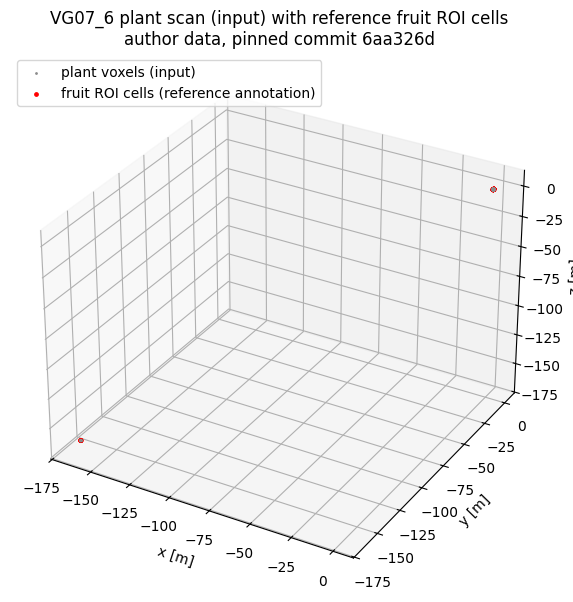

In [ ]:
import matplotlib.pyplot as plt

res_p, plant_leaves = parse_bt(files["VG07_6_0.01.bt"])
res_f, fruit_leaves = parse_bt(files["VG07_6_fruits_0.01.bt"])
assert res_p == res_f == 0.01

def leaf_points(leaves, res):
    pts = np.array([leaf_center_size(k, d, res)[0] for k, d, _ in leaves])
    szs = np.array([leaf_center_size(k, d, res)[1] for k, d, _ in leaves])
    return pts, szs

plant_pts, plant_sz = leaf_points(plant_leaves, res_p)
fruit_pts, fruit_sz = leaf_points(fruit_leaves, res_f)
print("plant voxels:", len(plant_pts), "| fruit ROI voxels:", len(fruit_pts))
print("fruit tree span (m):", fruit_pts.min(axis=0).round(3), "->", fruit_pts.max(axis=0).round(3))

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(plant_pts[::3, 0], plant_pts[::3, 1], plant_pts[::3, 2], s=1, c="0.55", label="plant voxels (input)")
ax.scatter(fruit_pts[:, 0], fruit_pts[:, 1], fruit_pts[:, 2], s=6, c="red", label="fruit ROI cells (reference annotation)")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.set_title("VG07_6 plant scan (input) with reference fruit ROI cells\nauthor data, pinned commit 6aa326d")
ax.legend(loc="upper left")
plt.show()

### Scenario 1 world: plant poses from `world14.world` / シナリオ1の植物配置
The paper's Scenario 1 is a four-plant environment with the UR5e arm on a static pole; `ur_with_cam_gazebo`'s
README gives `base:=static world_name:=world14` as the static-pole example. We parse the Gazebo world and find
exactly four capsicum plant instances: two `capsicum_plant_6` (with fruits) and two `capsicum_plant_6_no_fruits`.
The authors' `cfg/world_plant_locations/` YAMLs are not in the repository, so the world file is the authoritative
placement source; we map every `capsicum_plant_6*` model to the `VG07_6` trees (an inference documented here).

シナリオ1は静的ポール設置のUR5eと4つの植物からなる環境で、`world14.world`にその通り4つの
capsicum植物インスタンス（果実あり2 + 果実なし2）が定義されています。

In [ ]:
import xml.etree.ElementTree as ET

root = ET.parse(files["world14.world"]).getroot()
world = root.find("world")
plants = []
for m in world.findall("model"):
    name = m.get("name", "")
    if name.startswith("capsicum_plant"):
        pose = [float(v) for v in m.findtext("pose").split()]
        plants.append({"model": name, "has_fruits": "no_fruits" not in name, "location": pose[:3]})
assert len(plants) == 4, f"expected the 4-plant Scenario 1, got {len(plants)}"
for p in plants:
    print(p["model"], "fruits:" , p["has_fruits"], "| location (m):", p["location"])

capsicum_plant_6 fruits: True | location (m): [-0.484444, 0.000612, 0.0]
capsicum_plant_6_no_fruits fruits: False | location (m): [1.08363, 0.365261, 0.0]
capsicum_plant_6_no_fruits_0 fruits: False | location (m): [1.44414, 0.111247, 0.0]
capsicum_plant_6_0 fruits: True | location (m): [-0.276889, 0.624443, 0.0]


### Ground-truth reconstruction, faithful to `generate_gt_octree.cpp` / 地上真実の再構築
`roi_viewpoint_planner/src/generate_gt_octree.cpp` builds the world ground truth by translating the fruit-tree
leaf keys of each plant instance by `plantBaseKey - zeroKey` (`addKeys`) and inserting them into one tree. We do
exactly that integer key arithmetic for the two fruit-bearing plants (`capsicum_plant_6` and `capsicum_plant_6_0`),
and gather the plant-body keys of all four instances as occluders. This mirrors
`rvp_evaluation`'s `GtOctreeLoader` (per-fruit trees, `getTotalFruitCellCount`).
`generate_gt_octree.cpp`のキー並進（`addKeys`）を整数演算でそのまま再現し、果実あり2個体の果実セルと
4個体分の植物体セルをworldフレームに再構築します。

In [ ]:
GT_RES = 0.01  # m, author default tree_resolution
gt_tree = GT_RES  # resolution of the target tree equals the source trees

zero_key = coord_to_key(0.0, 0.0, 0.0, GT_RES)  # octomap ZERO_KEY
fruit_res, fruit_leaves = parse_bt(files["VG07_6_fruits_0.01.bt"])
plant_res, plant_leaves = parse_bt(files["VG07_6_0.01.bt"])
fruit_keys_full = sorted(expand_leaves(fruit_leaves, fruit_res))   # tree.expand() in the author code
plant_keys_full = sorted(expand_leaves(plant_leaves, plant_res))
print("expanded keys: fruits", len(fruit_keys_full), "| plant", len(plant_keys_full))

gt_fruit_keys = set()
plant_occ_keys = set()
for p in plants:
    loc = p["location"]
    plant_base_key = coord_to_key(loc[0], loc[1], loc[2], GT_RES)
    offset = tuple(bk - zk for bk, zk in zip(plant_base_key, zero_key))  # addKeys translation
    if p["has_fruits"]:
        for key in fruit_keys_full:
            gt_fruit_keys.add(tuple(k + o for k, o in zip(key, offset)))
    for key in plant_keys_full:
        plant_occ_keys.add(tuple(k + o for k, o in zip(key, offset)))

gt_fruit_pts = np.array([leaf_center_size(k, 15, GT_RES)[0] for k in gt_fruit_keys])
print("GT fruit cells:", len(gt_fruit_keys), " (= 2 plants x", len(fruit_leaves), "cells)")
print("GT plant-body cells (4 plants):", len(plant_occ_keys))
print("GT fruit volume:", round(len(gt_fruit_keys) * GT_RES**3 * 1e6, 1), "cm^3")

expanded keys: fruits 1656 | plant 13234
GT fruit cells: 3312  (= 2 plants x 1495 cells)
GT plant-body cells (4 plants): 52923
GT fruit volume: 3312.0 cm^3


### Scenario 1 ground truth in the world frame / シナリオ1のGT可視化
3D view of the reconstructed Scenario 1 ground truth: plant bodies (grey) and reference fruit ROI cells (red) for
the two fruit-bearing plants, in the `world` frame. Coordinates are from the author data + world file only.
再構築したシナリオ1のGTをworld座標系で可視化します（灰色: 植物体、赤: 参照果実セル）。

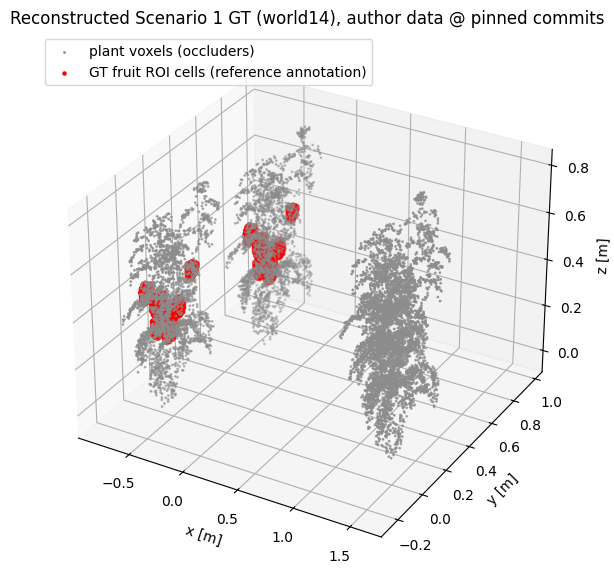

In [ ]:
plant_pts_gt = np.array([leaf_center_size(k, 15, GT_RES)[0] for k in plant_occ_keys])

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(plant_pts_gt[::5, 0], plant_pts_gt[::5, 1], plant_pts_gt[::5, 2], s=1, c="0.55",
           label="plant voxels (occluders)")
ax.scatter(gt_fruit_pts[:, 0], gt_fruit_pts[:, 1], gt_fruit_pts[:, 2], s=5, c="red",
           label="GT fruit ROI cells (reference annotation)")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.set_title("Reconstructed Scenario 1 GT (world14), author data @ pinned commits")
ax.legend(loc="upper left")
plt.show()

### Per-fruit statistics / 果実ごとの統計
`rvp_evaluation`'s `GtOctreeLoader` exposes per-fruit cell counts (`getFruitCellsCounts`). We count the leaf cells
of each individual fruit tree (`cfg/plant_files/individual_fruits/VG07_6/0.01/`, the same files the loader uses)
and compare with the ROI bounding boxes from `VG07_6_rois.yaml` (used by the authors' `generate_roi_yaml.py`).
Leaf cells outside a tight bbox are expected: bbox containment here uses voxel centers, and the author bbox is the
mesh bounding box. Results are exported to CSV inside the VM.
個々の果実ツリー（7個）のリーフセル数を数え、`VG07_6_rois.yaml`のROIバウンディングボックス体積と比較して
CSVに出力します。

In [ ]:
import pandas as pd

rois = yaml.safe_load(open(files["VG07_6_rois.yaml"]))
rows = []
for i in range(1, 8):
    res_i, leaves_i = parse_bt(files[f"VG07_6_fruit_{i}_0.01.bt"])
    pts_i, _ = leaf_points(leaves_i, res_i)
    mn, mx = np.array(rois[i - 1]["min"]), np.array(rois[i - 1]["max"])
    inside = int(((pts_i >= mn) & (pts_i <= mx)).all(axis=1).sum())
    rows.append({"fruit": i, "leaf_cells": len(leaves_i),
                 "cell_volume_cm3": round(sum(s**3 for s in
                     [leaf_center_size(k, d, res_i)[1] for k, d, _ in leaves_i]) * 1e6, 1),
                 "roi_bbox_volume_cm3": round((mx - mn).prod() * 1e6, 1),
                 "cells_inside_bbox": inside})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv("/content/gt_fruit_stats.csv", index=False)
print("saved /content/gt_fruit_stats.csv")

 fruit  leaf_cells  cell_volume_cm3  roi_bbox_volume_cm3  cells_inside_bbox
     1         151            165.0                230.1                126
     2         175            203.0                258.9                147
     3         141            155.0                170.4                110
     4         272            314.0                509.1                217
     5         249            277.0                312.4                  0
     6         205            219.0                460.0                  0
     7         305            326.0                534.4                269
saved /content/gt_fruit_stats.csv


## Adapted demonstration: ROI visibility and viewpoint utility (NOT author code)
**ADAPTED PYTHON DEMONSTRATION — この節は翻案です。** The paper scores candidate viewpoints with
`U = IG − α·C` (Sec. V-D, Eqs. 6–8) where IG is the expected ROI information gain and C the motion cost. The
author's implementation is C++ inside the ROS planner; we provide a small numpy illustration on the reconstructed
GT only, so the reader can see the quantities involved. Choices documented here that are **not** from the paper:
α = 0.5 (the paper gives α no numeric value), sensor range 0.3–0.5 m (taken from the author README's planner
defaults), ray sampling step 5 mm, viewpoints on rings around the plant. No claim of equivalence with the author's
planner is made.

**翻案の内容:** 論文V-D節のユーティリティ `U = IG − α·C` を、再構築したGT上で小さなnumpyデモとして可視化します。
αなどの値は論文に数値がないため本ノートブックでの選択であり、著者実装との等価性は主張しません。

### Build a dense occlusion grid for one fruit-bearing plant / 遮蔽用の密グリッド
For plant instance `capsicum_plant_6` at (−0.484, 0.0006, 0) we rasterize the translated plant-body voxels into a
dense boolean grid (1 cm cells) and map the GT fruit cells onto it. Fruit cells hidden behind plant voxels cannot
be seen; this is a simplified stand-in for the octree ray casting in the planner's `MULTI_RAY_UTILITY`.
`capsicum_plant_6`個体の植物体ボクセルを1 cm密グリッドにラスタライズし、GT果実セルをマッピングします。

In [ ]:
target = next(p for p in plants if p["model"] == "capsicum_plant_6" and p["has_fruits"])
loc = target["location"]
base_key = coord_to_key(loc[0], loc[1], loc[2], GT_RES)
offset = tuple(bk - zk for bk, zk in zip(base_key, zero_key))  # addKeys translation

loc_fruit = np.array([leaf_center_size(tuple(k + o for k, o in zip(key, offset)), 15, GT_RES)[0]
                      for key in fruit_keys_full])
loc_plant = np.array([leaf_center_size(tuple(k + o for k, o in zip(key, offset)), 15, GT_RES)[0]
                      for key in plant_keys_full])
print("plant cells:", len(loc_plant), "| fruit cells:", len(loc_fruit))

origin = loc_plant.min(axis=0) - 0.05
span = loc_plant.max(axis=0) - origin + 0.05
n_cells = np.ceil(span / GT_RES).astype(int)
grid = np.zeros(n_cells, dtype=bool)
idx = np.clip(((loc_plant - origin) / GT_RES).astype(int), 0, n_cells - 1)
grid[idx[:, 0], idx[:, 1], idx[:, 2]] = True
print("dense occlusion grid:", n_cells, "=", grid.size, "cells,", grid.sum(), "occupied")

plant cells: 13234 | fruit cells: 1656
dense occlusion grid: [58 70 94] = 381640 cells, 11321 occupied


### Sample candidate viewpoints and score them / 視点候補のサンプリングとスコアリング
Candidates: rings of camera positions around the plant center at distances 0.35/0.45/0.5 m and heights near the
fruit centroid, within the author's static workspace box (`config/static/workspace.yaml`: |x|,|y| ≤ 0.97 m,
0.01 ≤ z ≤ 1.91 m). For each candidate we cast one ray to every (sub-sampled) fruit cell and mark it visible if no
plant voxel is hit before the cell (sensor min range 0.3 m from the author README). IG := visible fruit cells /
total sampled; C := distance / 0.5 m; U = IG − α·C with α = 0.5 (documented choice).
候補視点は静的ワークスペース箱内のリング上に配置し、各果実セルへのレイが植物ボクセルに遮られずに
届くかでIGを、距離コストでCを定義し U = IG − α·C（α=0.5は本ノートブックの選択）でスコアリングします。

In [ ]:
center = loc_fruit.mean(axis=0)
rng = np.random.default_rng(0)  # deterministic sampling
sample_fruit = loc_fruit[rng.choice(len(loc_fruit), size=min(300, len(loc_fruit)), replace=False)]

cands = []
for dist in (0.35, 0.45, 0.50):
    for ang in np.linspace(0, 2 * np.pi, 16, endpoint=False):
        for dz in (-0.1, 0.0, 0.1):
            vp = center + np.array([dist * np.cos(ang), dist * np.sin(ang), dz])

            if (abs(vp[0]) <= 0.97 and abs(vp[1]) <= 0.97 and 0.01 <= vp[2] <= 1.91):
                cands.append(vp)
cands = np.array(cands)
print(len(cands), "candidate viewpoints in the static workspace box")

STEP = 0.005  # m
def visible_fraction(vp):
    dirs = sample_fruit - vp
    dists = np.linalg.norm(dirs, axis=1)
    ok = dists <= 0.5
    dirs = dirs[ok] / dists[ok, None]
    steps = np.clip((dists[ok] / STEP).astype(int), 1, 100)
    vis = np.zeros(len(dirs), bool)
    for j in range(len(dirs)):
        n = steps[j]
        t = (np.arange(1, n) / n)[:, None] * dists[ok][j]
        pts = vp + t * dirs[j]
        idx = ((pts - origin) / GT_RES).astype(int)
        idx = idx[((idx >= 0).all(axis=1) & (idx < n_cells).all(axis=1))]
        vis[j] = not grid[idx[:, 0], idx[:, 1], idx[:, 2]].any()
    return vis.sum() / len(sample_fruit), ok.sum() / len(sample_fruit)

ALPHA = 0.5  # documented notebook choice; the paper gives no numeric alpha
rows_v = []
for vp in cands:
    frac, reachable = visible_fraction(vp)
    cost = np.linalg.norm(vp - center) / 0.5
    rows_v.append((frac, cost, frac - ALPHA * cost, tuple(vp)))
rows_v.sort(key=lambda r: -r[2])
print("top 5 viewpoints by U = IG - alpha*C (alpha=%.1f):" % ALPHA)
for ig, c, u, vp in rows_v[:5]:
    print(f"  IG={ig:.3f} C={c:.2f} U={u:.3f} at ({vp[0]:.2f},{vp[1]:.2f},{vp[2]:.2f}) m")

126 candidate viewpoints in the static workspace box


top 5 viewpoints by U = IG - alpha*C (alpha=0.5):
  IG=0.203 C=0.70 U=-0.147 at (-0.94,0.03,0.34) m
  IG=0.177 C=0.73 U=-0.187 at (-0.91,0.17,0.24) m
  IG=0.167 C=0.73 U=-0.197 at (-0.94,0.03,0.24) m
  IG=0.143 C=0.70 U=-0.207 at (-0.91,-0.10,0.34) m
  IG=0.137 C=0.70 U=-0.213 at (-0.91,0.17,0.34) m


### Visualization: best viewpoint vs fruit visibility / 最良視点の可視化
Top-down view: plant voxels (grey), GT fruit cells (red), the highest-utility viewpoint (blue marker) and the fruit
cells visible from it (green). This is a notebook-created illustration of the adapted computation, not an author
figure.
上方から見た図: 植物体（灰）、GT果実セル（赤）、最良視点（青）、そこから可視の果実セル（緑）。
これは本ノートブックが作成した追加図であり、著者の図ではありません。

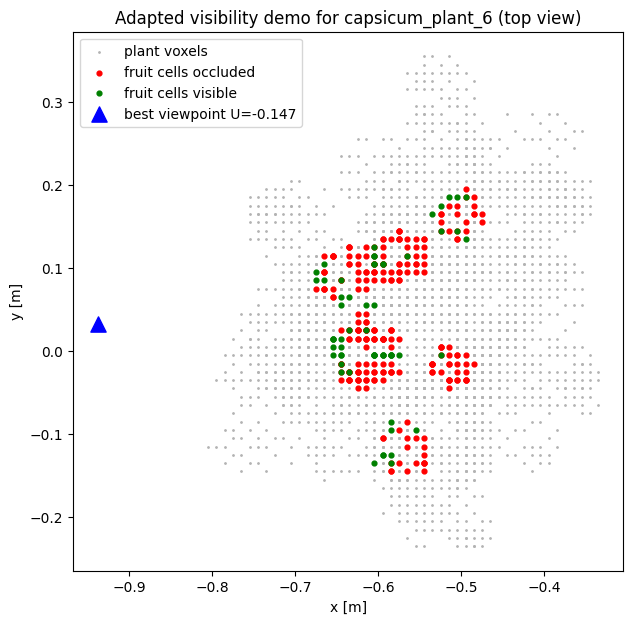

In [ ]:
best_vp = np.array(rows_v[0][3])
dirs = sample_fruit - best_vp
dists = np.linalg.norm(dirs, axis=1)
ok = dists <= 0.5
dirs = dirs[ok] / dists[ok, None]
vis = []
for j in range(len(dirs)):
    n = max(int(dists[ok][j] / STEP), 1)
    t = (np.arange(1, n) / n)[:, None] * dists[ok][j]
    pts = best_vp + t * dirs[j]
    idx = ((pts - origin) / GT_RES).astype(int)
    idx = idx[((idx >= 0).all(axis=1) & (idx < n_cells).all(axis=1))]
    vis.append(not grid[idx[:, 0], idx[:, 1], idx[:, 2]].any())
vis = np.array(vis)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(loc_plant[::5, 0], loc_plant[::5, 1], s=1, c="0.7", label="plant voxels")
sf = sample_fruit
ax.scatter(sf[~vis, 0], sf[~vis, 1], s=12, c="red", label="fruit cells occluded")
ax.scatter(sf[vis, 0], sf[vis, 1], s=12, c="green", label="fruit cells visible")
ax.scatter([best_vp[0]], [best_vp[1]], marker="^", s=120, c="blue", label=f"best viewpoint U={rows_v[0][2]:.3f}")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_title("Adapted visibility demo for capsicum_plant_6 (top view)")
ax.legend(loc="upper left"); ax.set_aspect("equal")
plt.show()

## Interpretation and limitations / 解釈と限界
**What was reproduced (faithful):** the author ground-truth pipeline — parsing the pinned OctoMap `.bt` plant/fruit
voxelizations, translating fruit keys per plant instance exactly as `generate_gt_octree.cpp::addKeys`, and
computing per-fruit cell counts/volumes as in `rvp_evaluation`'s `GtOctreeLoader`. Validated: parsed node counts
match the `.bt` headers, the fruits tree contains 7 fruit clusters consistent with the 7 ROI bboxes, and
`world14.world` contains exactly the four capsicum instances of Scenario 1.

**What was NOT reproduced:** the ROS/Gazebo closed-loop simulation (UR5e + MoveIt + octomap planner node), 3DMTS
local planning, HSI ROI detection on rendered images, camera-array modes, and the paper's Table I trials
(120 s, detected ROIs, covered ROI volume). The visibility/utility section is an explicitly adapted illustration
(α, ray sampling and viewpoint sampling are notebook choices, not paper values).

**Assumptions:** plant poses are taken from `world14.world` model poses (the authors'
`cfg/world_plant_locations/` YAMLs are not in the repository); the octree frame is assumed to coincide with the
model frame (possible mesh-origin offsets are a limitation). Author repository metadata reports no LICENSE file —
reuse terms must be verified by the operator.

**References:** Zaenker et al., "Combining Local and Global Viewpoint Planning for Fruit Coverage", ECMR 2021,
arXiv:2108.08114v1 · code: Eruvae/roi_viewpoint_planner @ 6aa326d, Eruvae/ur_with_cam_gazebo @ 69448a3,
Eruvae/rvp_evaluation @ 1392fc4 · OctoMap v1.9.8 (BSD) binary format reference.

**再現した内容:** ピン留め済み.octreeデータの解析、`generate_gt_octree.cpp`と同じキー並進によるGT再構築、
`rvp_evaluation`と同等の果実セル統計。**未再現:** ROS/Gazebo閉ループ、3DMTS、HSI検出、Table I試行。
可視化・ユーティリティ節は明示的な翻案デモです。